# Minerva Evals

## Results folders

In [1]:
from minerva_eval import load_all_results, get_run_summary, metrics_heatmap, EvalResult, Hit, gold_ranks
import pandas as pd
import json
from pathlib import Path
import re

all_results = load_all_results()

collections = {r.collection for r in all_results}
print(f"{len(all_results)} rows from {len(collections)} collections: {collections}")

450 rows from 2 collections: {'wikipedia-qwen2-5', 'wikipedia-nollm'}


## Run summary

One row per run folder: collection, timestamp, sweep matrix, query count.

In [2]:
run_summary = get_run_summary()
run_summary

,folder,collection,timestamp,sweep,queries,rows
0,2026-08-19T12-47-23Z_wikipedia-v1,wikipedia-qwen2-5,2026-08-19T12:47:23Z,"top_k=[50] alpha=[0.3, 0.5, 0.7]",75,225
1,2026-08-19T13-36-06Z_wikipedia-v1,wikipedia-nollm,2026-08-19T13:36:06Z,"top_k=[50] alpha=[0.3, 0.5, 0.7]",75,225


## Metrics view

Mean over queries, grouped by `(collection, hybrid_alpha)`. Reproduces the
headline table from the sweep-findings spec; styled as a heatmap.

In [3]:
heatmap = metrics_heatmap(all_results)
heatmap

## Wrong queries finder

Pick failures for R@10 for any $\alpha$ as they may potentially identify wrong gold sources

In [7]:
from collections import defaultdict

def persistent_failures(collection: str, metric: str, threshold: float = 1.0):
    # aggregates all_results by query id
    by_query = defaultdict(list)
    for r in all_results:
        if r.collection == collection:
            by_query[r.query_id].append(r)
    return [rs for rs in by_query.values()
            if all(getattr(r.metrics, metric) < threshold for r in rs)]

metric = "recall_at_10"
# failures = pick_failures("wikipedia-nollm", 0.5, metric)
failures = persistent_failures("wikipedia-nollm", metric)

print(f"{len(failures)} suspect queries")
pd.DataFrame([
    { 
     "query_id": r[0].query_id, 
     "query": r[0].query, 
     "metric_0": getattr(r[0].metrics, metric), 
     "metric_1": getattr(r[1].metrics, metric),
     "metric_2": getattr(r[2].metrics, metric)}
    for r in failures
])

4 suspect queries


,query_id,query,metric_0,metric_1,metric_2
0,Virus.md-2,submicroscopic agents that are considered at t...,0.50,0.5,0.5
1,Antarctica.md-1,Where do live emperor penguins?,0.50,0.5,0.5
2,Antarctica.md-3,what place on earth do scientists use to study...,0.00,0.5,0.5
3,Long_Depression.md-1,Were there other periods of economic crisis in...,0.25,0.0,0.0


## Failure picker

For a chosen `(collection, hybrid_alpha, metric)`, return the suspect rows —
queries scoring below `threshold` on that metric. Default `threshold=1.0` catches
partial misses, not only full zeros. These rows feed the audit view.

In [ ]:

def persistent_failures(collection: str, metric: str, threshold: float = 1.0):
    # aggregates all_results by query id
    by_query = defaultdict(list)
    for r in all_results:
        if r.collection == collection:
            by_query[r.query_id].append(r)
    return [rs for rs in by_query.values()
            if all(getattr(r.metrics, metric) < threshold for r in rs)]

# def pick_failures(collection: str, alpha: float, metric: str,
#                   threshold: float = 1.0) -> list[EvalResult]:
#     return [r for r in all_results
#             if r.collection == collection
#             and r.cell.hybrid_alpha == alpha
#             and getattr(r.metrics, metric) < threshold]

# spec example: (wikipedia-nollm, alpha=0.5, recall_at_10)
metric = "recall_at_10"
# failures = pick_failures("wikipedia-nollm", 0.5, metric)
failures = persistent_failures("wikipedia-nollm", metric)

print(f"{len(failures)} suspect queries")
pd.DataFrame([
    {"query_id": r.query_id, "query": r.query, metric: getattr(r.metrics, metric)}
    for r in failures
])

7 suspect queries


,query_id,query,recall_at_10
0,The_Beatles.md-2,Which english music band derived its name from...,0.000000
1,Wireless_network.md-1,Data transmission without wires,0.666667
2,List_of_Roman_emperors.md-1,Which term do we use today to name the princep...,0.500000
3,Virus.md-2,submicroscopic agents that are considered at t...,0.500000
4,Antarctica.md-1,Where do live emperor penguins?,0.500000
5,Antarctica.md-3,what place on earth do scientists use to study...,0.500000
6,Long_Depression.md-1,Were there other periods of economic crisis in...,0.000000


## Audit view

For each failing query: the gold article(s) with a corpus snippet, plus the
deduplicated top-10 retrieved articles (rank + GOLD marker). Lets each miss be
classified as a real retrieval failure or a mislabeled gold.

The corpus path is read from `config.local.json` (gitignored, machine-specific).
Copy `config.local.json.example` and set `corpus_dir`.

In [7]:
config = json.loads(Path("config.local.json").read_text())
CORPUS_DIR = Path(config["corpus_dir"])

def read_snippet(source_id: str, max_chars: int = 300) -> str:
    text = (CORPUS_DIR / source_id).read_text()
    body = re.sub(r"^---\n.*?\n---\n", "", text, count=1, flags=re.DOTALL)  # drop frontmatter
    paras = [s for p in body.split("\n\n") if (s := p.strip()) and not s.startswith("#")]
    snippet = paras[0] if paras else ""
    return snippet[:max_chars] + ("…" if len(snippet) > max_chars else "")

def top_articles(hits: list[Hit], k: int = 10) -> list[Hit]:
    seen, out = set(), []
    for h in sorted(hits, key=lambda h: h.rank):
        if h.source_id not in seen:
            seen.add(h.source_id)
            out.append(h)
        if len(out) == k:
            break
    return out

def audit(failures: list[EvalResult]) -> None:
    for r in failures:
        print(f"=== {r.query_id}  recall_at_10={r.metrics.recall_at_10} ===")
        print(f"query: {r.query!r}")
        for g in r.gold_sources:
            print(f"gold  [{g}]: {read_snippet(g)}")
        print("top-10 articles:")
        for h in top_articles(r.hits):
            mark = "GOLD" if h.source_id in r.gold_sources else "    "
            print(f"  {h.rank:>2} {mark} {h.source_id}  ({h.score:.4f})")
        print()

audit(failures)

=== The_Beatles.md-2  recall_at_10=0.0 ===
query: 'Which english music band derived its name from the common name for Coleoptera?'
gold  [The_Beatles.md]: This article is about the band. For their eponymous album, see [*The Beatles* (album)](The_Beatles_(album) "The Beatles (album)"). For other uses, see Beatles (disambiguation).
top-10 articles:
   1      Beetle.md  (0.0125)
   2      Red_fox.md  (0.0113)
   3      Chris_Martin.md  (0.0112)
   4      New_Zealand_English.md  (0.0112)
   6      Germany.md  (0.0110)
   7      Ozzy_Osbourne.md  (0.0110)
  10      Yellowhammer.md  (0.0108)
  11      Indonesian_language.md  (0.0107)
  12 GOLD The_Beatles.md  (0.0107)
  14      Antarctica.md  (0.0106)



## Gold rank across cells

For one query, the gold article's best chunk rank in every `(collection, alpha)`
cell. `rank <= 10` == recall@10 hit; `rank == top_k+1` (51) == gold beyond `top_k`
(a coverage miss, not a ranking miss). Compare `nollm` vs `qwen2-5` at matched
alpha to test whether contextualization improves ranking.

In [8]:
def gold_chunk_ranks(query_id: str) -> pd.DataFrame:
    """Gold source rank per (collection, alpha) cell, for one query.
    rank <= 10 == recall@10 hit; rank == top_k+1 == gold beyond top_k (coverage miss)."""
    ranks = pd.DataFrame(vars(g) for g in gold_ranks(all_results))
    ranks = ranks[ranks["query_id"] == query_id]
    return ranks.pivot_table(index=["gold", "collection"], columns="alpha",
                             values="rank", aggfunc="first")

gold_chunk_ranks("The_Beatles.md-2")

alpha                             0.3  0.5  0.7
gold           collection                      
The_Beatles.md wikipedia-nollm     14   12    6
               wikipedia-qwen2-5   14    3    2

## Gold rank per query — collection comparison

The whole-sample version of the cell above. At a fixed alpha, plot each query's
gold rank under `nollm` (x) against `qwen2-5` (y). Points **below** the diagonal
are queries where contextualization ranks the gold better; distance from the line
is the magnitude; cluster tightness is the consistency. The printed counts and
median rank delta summarize what the MRR@10 mean in the metrics view hides: the
pairing, the spread, and any regressions.

Missing gold (beyond `top_k`) maps to `top_k + 1`, so coverage misses plot at the
edge rather than dropping out.

alpha=0.5  wikipedia-qwen2-5 vs wikipedia-nollm:  better: 11  worse: 7  tied: 37  median delta: 0.0


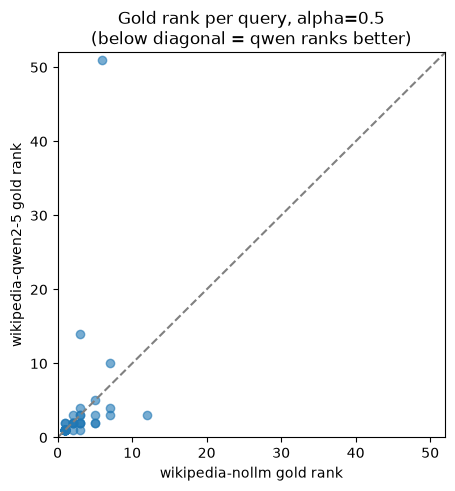

In [9]:
import matplotlib.pyplot as plt

def gold_rank_per_query(alpha: float) -> pd.DataFrame:
    """Worst gold rank per query, one column per collection, at a fixed alpha.
    Missing gold (beyond top_k) is already mapped to top_k+1 by gold_ranks, so it plots as 'worst'."""
    ranks = pd.DataFrame(vars(g) for g in gold_ranks(all_results))
    ranks = ranks[ranks["alpha"] == alpha]
    return ranks.pivot_table(index="query_id", columns="collection",
                             values="rank", aggfunc="max")

ALPHA = 0.5
A, B = "wikipedia-nollm", "wikipedia-qwen2-5"

cmp = gold_rank_per_query(ALPHA)
delta = cmp[B] - cmp[A]
print(f"alpha={ALPHA}  {B} vs {A}:  "
      f"better: {(delta < 0).sum()}  worse: {(delta > 0).sum()}  "
      f"tied: {(delta == 0).sum()}  median delta: {delta.median()}")

lim = 52
fig, ax = plt.subplots(figsize=(5, 5))
ax.scatter(cmp[A], cmp[B], alpha=0.6)
ax.plot([0, lim], [0, lim], "--", color="gray")
ax.set_xlabel(f"{A} gold rank")
ax.set_ylabel(f"{B} gold rank")
ax.set_title(f"Gold rank per query, alpha={ALPHA}\n(below diagonal = qwen ranks better)")
ax.set_xlim(0, lim)
ax.set_ylim(0, lim)
plt.show()